# Using observed data from WTI and TB3M

In [12]:
import pandas as pd
import numpy as np
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import importlib
import my_lstm
importlib.reload(my_lstm)

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast

In [13]:
df = pd.read_csv('../data/final_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302,-0.394190
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699,-0.203766
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697,0.018075
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797,0.180503
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716,-0.135577


In [14]:
feature_cols = [
    "TB3MS",
    "wti_ret"
]

target_col = "wti_ret"

In [15]:
df = df.sort_values("Date").reset_index(drop=True)

# data split into 70/15/15
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
val_end = train_size + val_size


# split using iloc 
train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

# print length of data in each set
print(f'Train data length: {len(train_data)}')
print(f'Validation data length: {len(val_data)}')
print(f'Test data length: {len(test_data)}')

Train data length: 336
Validation data length: 72
Test data length: 72


In [7]:
# grid search over hyperparameters for the expanding window LSTM
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
} 
param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    try:
        val_forecasts = expanding_window_lstm_forecast(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            initial_train_size=train_size,
            end_idx=val_end,
            date_col="Date",
            lookback=lb,
            units=units,
            dropout=dr,
            epochs=ep,
            batch_size=32,
            verbose=0,
            scale=True,
            seed=42
        )

        if len(val_forecasts) == 0:
            print("No forecasts generated, skipping.")
            continue

        mse = mean_squared_error(
            val_forecasts["actual"],
            val_forecasts["predicted"]
        )

        print(f"Validation MSE: {mse:.6f}")

        results_grid.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep,
            "mse": mse
        })

    except Exception as e:
        print(f"Error: {e}")
        continue



[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50


Validation MSE: 0.035556

[2/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=100
Validation MSE: 0.038118

[3/16] Testing params:
lookback=2, dropout=0.001, units=170, epochs=50
Validation MSE: 0.038459

[4/16] Testing params:
lookback=2, dropout=0.001, units=170, epochs=100
Validation MSE: 0.038532

[5/16] Testing params:
lookback=2, dropout=0.1, units=50, epochs=50
Validation MSE: 0.038972

[6/16] Testing params:
lookback=2, dropout=0.1, units=50, epochs=100
Validation MSE: 0.038972

[7/16] Testing params:
lookback=2, dropout=0.1, units=170, epochs=50
Validation MSE: 0.041375

[8/16] Testing params:
lookback=2, dropout=0.1, units=170, epochs=100
Validation MSE: 0.041375

[9/16] Testing params:
lookback=10, dropout=0.001, units=50, epochs=50
Validation MSE: 0.140212

[10/16] Testing params:
lookback=10, dropout=0.001, units=50, epochs=100
Validation MSE: 0.413419

[11/16] Testing params:
lookback=

In [8]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.0355562585624257},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.0381181898458919},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.03845912440068149},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.038531798969890195},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.03897155691185897},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.03897155691185897},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.04137518495640615},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.04137518495640615},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.14021221255478664},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.41341914356065046},
 {'lookb

In [3]:
import pandas as pd

In [4]:
results_grid = pd.DataFrame([{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.0355562585624257},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.0381181898458919},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.03845912440068149},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.038531798969890195},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.03897155691185897},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.03897155691185897},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.04137518495640615},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.04137518495640615},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.14021221255478664},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.41341914356065046},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 170,
  'epochs': 50,
  'mse': 0.2773891984746929},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.29267228733344236},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.08363668125611448},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.09279871551637403},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.2672247224760134},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.28119095446002135}])

In [7]:
results_grid.sort_values("mse")

,lookback,dropout,units,epochs,mse
0,2,0.001,50,50,0.035556
1,2,0.001,50,100,0.038118
2,2,0.001,170,50,0.038459
3,2,0.001,170,100,0.038532
4,2,0.100,50,50,0.038972
5,2,0.100,50,100,0.038972
6,2,0.100,170,50,0.041375
7,2,0.100,170,100,0.041375
12,10,0.100,50,50,0.083637
13,10,0.100,50,100,0.092799


In [8]:
results_df = pd.DataFrame(results_grid)
results_df = results_df.sort_values("mse")

print(results_df.head())

best_params = results_df.iloc[0]
print(best_params)

   lookback  dropout  units  epochs       mse
0         2    0.001     50      50  0.035556
1         2    0.001     50     100  0.038118
2         2    0.001    170      50  0.038459
3         2    0.001    170     100  0.038532
4         2    0.100     50      50  0.038972
lookback     2.000000
dropout      0.001000
units       50.000000
epochs      50.000000
mse          0.035556
Name: 0, dtype: float64


# Out of sample testing

In [16]:
test_results = expanding_window_lstm_forecast(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,  
    end_idx=len(df),    
    date_col="Date",        
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)




Test MSE: 0.19046498725800834
Test MAPE: 5.981877849405688
Test R²: -9.051976499477048


In [17]:
# export test results to csv
test_results.to_csv('results/lstm1_test_results.csv', index=False)

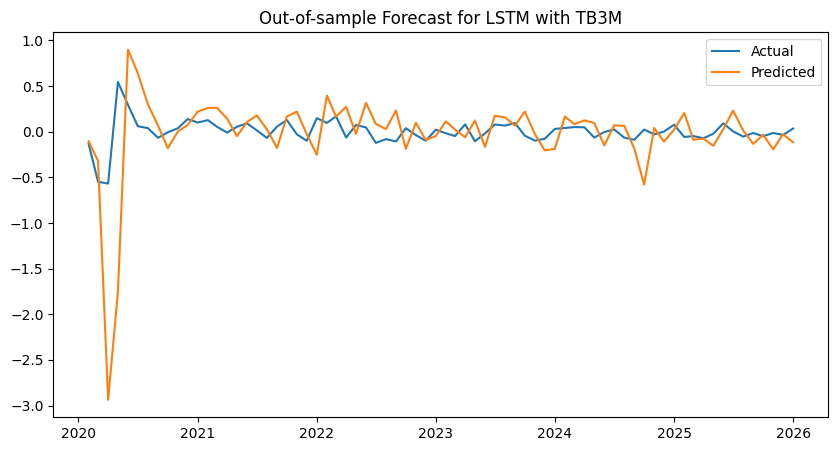

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM with TB3M")
plt.show()